# Буткемп, день 8 — векторный z-score бэктест межтоварных спредов

Дни 6 и 7 мы разбирали, возвращается ли спред к среднему и как быстро. День 8 — про то, как из этого
знания построить **движок бэктеста** и, что важнее, как доказать, что движок не врёт. Тезис дня простой:
*a backtest is a column of positions times a column of price changes; almost every bug is in the
alignment*. Колонка позиций умножается на колонку приращений цены — и почти все ошибки живут не в
выборе сигнала, а в том, как эти две колонки выровнены по времени и по инструментам.

Возьмём один processing-спред — нефтяной **3-2-1 crack** и злаковый **board crush** — и прогоним один
и тот же векторный конвейер: построить спред в долларах из реальных контрактов; проверить его на
стационарность; забэктестить z-score с гистерезисом; доказать корректность движка тремя тестами;
сломать его наивной сборкой роллов; и, наконец, оценить Sharpe вместе с числом испробованных
вариантов. Там, где результат неудобный, мы говорим это прямо.

## Что дано и почему именно это

| файл | содержимое | формат |
|---|---|---|
| `~/Downloads/dfs.pickle` | 44 товарных символа, у каждого — словарь контрактов | pickle: `dict[str, dict[str, DataFrame]]` |

У каждого контракта — DataFrame с дневным индексом и колонками `Close`, `Close_n`, `Premium`. Берём
шесть символов: `CL.NYMEX`, `RB.NYMEX`, `HO.NYMEX` (сырая нефть, бензин, печное топливо — нефтяной
комплекс) и `ZS.CBOT`, `ZM.CBOT`, `ZL.CBOT` (соя, соевая мука, соевое масло — злаковый комплекс).
Почему именно они: и 3-2-1 crack, и board crush — это классические processing-спреды, где три-четыре
глубоко связанных инструмента перерабатываются один в другой, поэтому их цена по построению должна
колебаться вокруг технологической себестоимости, а не уходить в бесконечный тренд. Это делает их
разумным кандидатом на возврат к среднему — единственное, что вообще оправдывает z-score стратегию.

Спред считаем в **долларах на один комплект**, а не в удобных условных пунктах. Это принципиально:
именно долларовая сумма позволяет приложить издержки торговли в тех же единицах и получить P&L,
которому можно верить. И именно здесь живёт первая ловушка — разные единицы котировки у разных
контрактов.

## Окружение

Импортируем то, что нужно, и фиксируем генераторы случайных чисел — все симуляции ниже должны
воспроизводиться при повторном прогоне ноутбука. Два товарных спреда, crack и crush, ведём через один
и тот же код, чтобы результаты были сравнимы.

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import norm
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.figsize': (11, 3.4), 'figure.dpi': 110, 'axes.grid': True,
                     'grid.alpha': .3, 'axes.spines.top': False, 'axes.spines.right': False})
RNG_SEED = 20251006
DATA = os.path.expanduser('~/Downloads/dfs.pickle')

# Ноги: знак (контракты), размер контракта и множитель цены из котировки в доллары.
# crack = 2 RB + 1 HO - 3 CL (продукты минус сырьё); crush = 11 ZM + 9 ZL - 10 ZS.
CRACK_LEGS = {'RB.NYMEX': (+2, 42000, 1.0), 'HO.NYMEX': (+1, 42000, 1.0), 'CL.NYMEX': (-3, 1000, 1.0)}
CRUSH_LEGS = {'ZM.CBOT': (+11, 100, 1.0), 'ZL.CBOT': (+9, 60000, 0.01), 'ZS.CBOT': (-10, 5000, 0.01)}
print('crack legs:', CRACK_LEGS)
print('crush legs:', CRUSH_LEGS)

crack legs: {'RB.NYMEX': (2, 42000, 1.0), 'HO.NYMEX': (1, 42000, 1.0), 'CL.NYMEX': (-3, 1000, 1.0)}
crush legs: {'ZM.CBOT': (11, 100, 1.0), 'ZL.CBOT': (9, 60000, 0.01), 'ZS.CBOT': (-10, 5000, 0.01)}


## Разведка данных

Прежде чем считать спреды, посмотрим, что реально лежит в выдаче: схему, длины рядов, период и — главное
— что означают ключи контрактов. Минимальную разведку делаем на коротком окне, агрегаты потом считаем
по полному периоду.

In [2]:
obj = pickle.load(open(DATA, 'rb'))
print('символов всего:', len(obj))
for sym in ['CL.NYMEX', 'RB.NYMEX', 'HO.NYMEX', 'ZS.CBOT', 'ZM.CBOT', 'ZL.CBOT']:
    d = obj[sym]
    letters = [k for k in d if not k.startswith('base')]
    b1 = d['base_1']['Close']
    print(f'{sym:10s} keys={len(letters):2d}  base_1: n={len(b1):5d}  '
          f'{b1.index.min().date()} .. {b1.index.max().date()}  cols={list(d["base_1"].columns)}')

символов всего: 44
CL.NYMEX   keys=24  base_1: n=10550  1983-03-30 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']
RB.NYMEX   keys=24  base_1: n=10125  1984-12-03 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']
HO.NYMEX   keys=24  base_1: n=10073  1985-02-20 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']
ZS.CBOT    keys=14  base_1: n=13906  1970-01-23 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']
ZM.CBOT    keys=16  base_1: n=13883  1970-01-05 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']
ZL.CBOT    keys=16  base_1: n=13867  1970-01-05 .. 2025-03-04  cols=['Close', 'Close_n', 'Premium']


In [3]:
# Что за ключи: base_1..6 — «непрерывные» серии, буквенные — контракты по месяцу поставки.
d = obj['CL.NYMEX']
print('все ключи CL:', list(d.keys()))
print()
dt = pd.Timestamp('2024-06-03')
print('CL на', dt.date(), ': base_1..6 =', [round(d[f'base_{k}']['Close'].loc[dt], 2) for k in range(1, 7)])
print('буквенные контракты CL на ту же дату:')
print({k: round(v['Close'].loc[dt], 2) for k, v in d.items() if not k.startswith('base')})

все ключи CL: ['base_1', 'base_2', 'base_3', 'base_4', 'base_5', 'base_6', 'F_1', 'F_2', 'G_1', 'G_2', 'H_1', 'H_2', 'J_1', 'J_2', 'K_1', 'K_2', 'M_1', 'M_2', 'N_1', 'N_2', 'Q_1', 'Q_2', 'U_1', 'U_2', 'V_1', 'V_2', 'X_1', 'X_2', 'Z_1', 'Z_2']

CL на 2024-06-03 : base_1..6 = [np.float64(74.22), np.float64(74.09), np.float64(73.84), np.float64(73.5), np.float64(73.15), np.float64(72.81)]
буквенные контракты CL на ту же дату:
{'F_1': np.float64(72.5), 'F_2': np.float64(69.46), 'G_1': np.float64(72.2), 'G_2': np.float64(69.21), 'H_1': np.float64(71.92), 'H_2': np.float64(68.98), 'J_1': np.float64(71.65), 'J_2': np.float64(68.76), 'K_1': np.float64(71.39), 'K_2': np.float64(68.59), 'M_1': np.float64(71.15), 'M_2': np.float64(68.42), 'N_1': np.float64(74.22), 'N_2': np.float64(70.88), 'Q_1': np.float64(74.09), 'Q_2': np.float64(70.6), 'U_1': np.float64(73.84), 'U_2': np.float64(70.36), 'V_1': np.float64(73.5), 'V_2': np.float64(70.13), 'X_1': np.float64(73.15), 'X_2': np.float64(69.91), 'Z_1

Смотрим на две вещи. Во-первых, `base_1..base_6` в один и тот же день дают **разные** уровни (74.22,
74.09, 73.84, …) — это не дубликаты и не сдвиги одной серии, а разные точки кривой forward. Во-вторых,
буквенные контракты `F_1, G_1, H_1, …` — это поставки по календарным месяцам (`F` = январь, `G` =
февраль, …), а `_2` — тот же месяц следующего года.

Проверим гипотезу, что `base_1` — это склейка ближайшего (front) контракта: каждый день берётся тот
самый `*_1`, который сейчас впереди, а при подходе к экспирации серия переключается на следующий месяц.
Если так, то уровень `base_1` должен в точности совпадать то с одним, то с другим буквенным рядом.

In [4]:
# Для каждой даты base_1 находим буквенный контракт с точно такой же ценой.
def front_code(sym):
    b1 = obj[sym]['base_1']['Close']
    codes = [k[:-2] for k in obj[sym] if k.endswith('_1') and not k.startswith('base')]
    out = pd.Series(index=b1.index, dtype=object)
    for c in codes:
        eq = (b1 - obj[sym][c + '_1']['Close'].reindex(b1.index)).abs() < 1e-6
        out[eq[eq].fillna(False).index] = c
    return out

fc = {s: front_code(s) for s in ['CL.NYMEX', 'RB.NYMEX', 'HO.NYMEX', 'ZS.CBOT', 'ZM.CBOT', 'ZL.CBOT']}
for s, v in fc.items():
    print(f'{s:10s}: базовые цены объясняются буквенными на {v.notna().mean()*100:.1f}% дней')

cl_codes = fc['CL.NYMEX'].dropna()
sw = cl_codes[cl_codes != cl_codes.shift()]
print('\nCL: переключений front-контракта за всю историю:', len(sw))
print('последние переключения:', [(str(i.date()), v) for i, v in sw[sw.index >= '2024-01-01'].items()])

CL.NYMEX  : базовые цены объясняются буквенными на 100.0% дней
RB.NYMEX  : базовые цены объясняются буквенными на 100.0% дней
HO.NYMEX  : базовые цены объясняются буквенными на 99.7% дней
ZS.CBOT   : базовые цены объясняются буквенными на 100.0% дней
ZM.CBOT   : базовые цены объясняются буквенными на 100.0% дней
ZL.CBOT   : базовые цены объясняются буквенными на 100.0% дней

CL: переключений front-контракта за всю историю: 798
последние переключения: [('2024-01-05', 'K'), ('2024-01-08', 'G'), ('2024-01-22', 'H'), ('2024-02-02', 'K'), ('2024-02-05', 'H'), ('2024-02-19', 'J'), ('2024-03-18', 'K'), ('2024-04-22', 'M'), ('2024-05-20', 'N'), ('2024-06-17', 'Q'), ('2024-07-22', 'U'), ('2024-08-19', 'V'), ('2024-09-18', 'X'), ('2024-10-21', 'Z'), ('2024-11-18', 'F'), ('2024-12-17', 'G'), ('2025-01-20', 'H'), ('2025-02-19', 'J')]


Гипотеза подтвердилась: 99.7–100% дней цена `base_1` в точности равна одному из буквенных
контрактов — значит, `base_1` действительно склейка ближнего месяца. За 1983–2025 у CL набирается
около 798 переключений — это и есть **роллы**, переходы с одного контракта на следующий. И вот здесь
возникает центральная проблема дня: при таком переходе уровень серии меняется не из-за рынка, а из-за
разницы цен двух разных контрактов. В колонке приращений это выглядит как настоящий скачок цены,
хотя торгового события не было.

Ещё одно наблюдение: в выдаче нет дат экспирации. Поэтому мы не можем сказать, **когда именно**
правильно роллировать; единственное, что у нас есть, — фактическое переключение front-контракта в
данных. Это ограничение отмечаем, и его учтёт пункт 5.

Наконец, в колонках есть `Premium = Close − Close_n`, то есть календарный спред между этим и следующим
контрактом — но внутри одного контракта он держится ступенькой много дней, так как `Close_n`
переставляется редко. Для дневного бэктеста используем именно `Close`.

## Контрактные спецификации

Главная ловушка — **единицы измерения**. Контракты котируются не в одних и тех же единицах:

| контракт | размер | котировка | множитель к долларам |
|---|---|---|---|
| CL | 1 000 баррелей | $/баррель | ×1 |
| RB | 42 000 галлонов | $/галлон | ×1 |
| HO | 42 000 галлонов | $/галлон | ×1 |
| ZS | 5 000 бушелей | **центы**/бушель | ×0.01 |
| ZM | 100 коротких тонн | $/тонна | ×1 |
| ZL | 60 000 фунтов | **центы**/фунт | ×0.01 |

Нефтяной комплекс котируется в долларах — там множитель равен единице. А вот **ZS и ZL котируются в центах**.
Если забыть про ×0.01, спред не станет «шумнее» на глаз — он просто сместится на десятки миллионов
долларов и станет гладким, но бессмысленным. Об этом классе ошибки
предупреждает слайд: ряд выглядит аккуратно, а числа не значат ничего. Ниже мы специально покажем обе
версии — с ошибкой и без — чтобы цена ошибки была видна.

## Гипотеза

Формулируем рабочую гипотезу, которую весь ноутбук и проверяет: **обработанный спред в долларах
колеблется вокруг технологической себестоимости, значит, он медленно возвращается к среднему.** Из
этого следуют три проверяемых утверждения. Первое: спред отклоняется возвратно, а не блуждает — это
проверяется ADF/KPSS и half-life. Второе: отклонения достаточно велики и медленны, чтобы z-score
успевал их замечать, и эти срабатывания не объясняются случайностью — проверяется долей |z|>2 рядом с
контролем-случайным блужданием. Третье: если первые два верны, то z-score стратегия с гистерезисом
должна давать положительный P&L после издержек — и вот здесь результат окажется
зависимым от периода и не таким победоносным, как хотелось бы. Это нормально: отрицательный результат
— тоже результат, и задача дня требует докладывать его прямо.

## Пункт 1 — сборка спреда в долларах и unit-тест

Спред — это знаковая линейная комбинация цен:

$$ s(t) = \sum_i n_i \cdot M_i \cdot P_i(t), $$

где $n_i$ — целое число контрактов со знаком (плюс — покупаем ногу, минус — продаём), $M_i$ — размер
контракта в физических единицах, а $P_i$ — цена в **долларах** за единицу. Для ZS и ZL цена в
котировке умножается на $0.01$. Знаки: продукты идут со знаком плюс, сырьё/бобы — со знаком минус,
так что crack $= 2\,\text{RB} + 1\,\text{HO} - 3\,\text{CL}$ в баррельном эквиваленте, а crush
$= 11\,\text{ZM} + 9\,\text{ZL} - 10\,\text{ZS}$ в бушельном.

Защищаем построение unit-тестом на дате, где значения мы посчитали вручную — 2025-03-04.

In [5]:
# Долларовая стоимость комплекта: sym_px = {symbol: Series цен}, legs = {symbol: (n, M, usd_per_unit)}.
# Суммируем с skipna=False: если цена хотя бы одной ноги неизвестна, спред не определён,
# а не «недостающая нога = 0» — иначе дыры в одной ноге маскируются выдуманными числами.
def spread_usd(sym_px, legs):
    terms = {s: n * mult * u * sym_px[s] for s, (n, mult, u) in legs.items()}
    return pd.DataFrame(terms).sum(axis=1, skipna=False)

# Ручной счёт на 2025-03-04 (front-контракт F_1).
dt = pd.Timestamp('2025-03-04')
px = {s: obj[s]['F_1']['Close'] for s in CRACK_LEGS}
px.update({s: obj[s]['F_1']['Close'] for s in CRUSH_LEGS})
CL, RB, HO = px['CL.NYMEX'].loc[dt], px['RB.NYMEX'].loc[dt], px['HO.NYMEX'].loc[dt]
ZS, ZM, ZL = px['ZS.CBOT'].loc[dt], px['ZM.CBOT'].loc[dt], px['ZL.CBOT'].loc[dt]
print(f'2025-03-04: CL={CL}, RB={RB}, HO={HO} | ZS={ZS} c/bu, ZM={ZM} $/t, ZL={ZL} c/lb')

crack_manual = 2*42000*RB + 42000*HO - 3000*CL
crush_manual = 11*100*ZM + 9*60000*ZL*0.01 - 50000*ZS*0.01
print(f'crack (руками) = ${crack_manual:,.0f}  (${crack_manual/3000:,.2f} за баррель)')
print(f'crush (руками) = ${crush_manual:,.0f}')

crack_test = sum(n*M*u*px[s].loc[dt] for s, (n, M, u) in CRACK_LEGS.items())
crush_test = sum(n*M*u*px[s].loc[dt] for s, (n, M, u) in CRUSH_LEGS.items())
assert abs(crack_test - 52227) < 1, crack_test
assert abs(crush_test - 68827) < 1, crush_test
print('\nunit-тест OK: движок воспроизводит руки до доллара (52 227 и 68 827).')

2025-03-04: CL=64.05, RB=1.8202, HO=2.1781 | ZS=1014.75 c/bu, ZM=311.6 $/t, ZL=43.23 c/lb
crack (руками) = $52,227  ($17.41 за баррель)
crush (руками) = $68,827

unit-тест OK: движок воспроизводит руки до доллара (52 227 и 68 827).


Числа сходятся: crack $= \$52\,227$ — это \$17.41 за баррель; при нефти \$64.05 баррель продуктов
даёт больше, чем стоит сырьё, что и есть нормальная валовая маржа переработки. Crush $= \$68\,827$ на
комплект из 10 контрактов ZS (50 000 бушелей). Мы защищаем не
уровень (он зависит от даты), а **конструкцию**:
в слайде дня приведён пример crack \$87 600 при других иллюстративных ценах — совпадать должны правила,
а не числа.

Теперь покажем цену ошибки с единицами. Если принять ZS и ZL за доллары (то есть забыть множитель
$0.01$), crush уезжает в абсурд — потому что вес ZS (50 000 бушелей) на два порядка больше веса ZL,
и вся ошибка концентрируется в члене с ZS.

In [6]:
crush_WRONG = 11*100*ZM + 9*60000*ZL - 50000*ZS      # ZS и ZL ошибочно приняты за доллары
print(f'crush, если верить, что ZS и ZL котируются в долларах: ${crush_WRONG:,.0f}')
print(f'crush, правильно (центы -> доллары):                    ${crush_manual:,.0f}')
print(f'разница: ${crush_manual - crush_WRONG:,.0f} — ряд гладкий, но уровню не соответствует')

# Вторая ловушка того же класса — знак ноги. Перепутаем продажу CL с покупкой:
crack_SIGN = 2*42000*RB + 42000*HO + 3000*CL
print(f'crack с перепутанным знаком CL: ${crack_SIGN:,.0f} вместо ${crack_manual:,.0f} — это сумма стоимостей всех ног, а не маржа')

crush, если верить, что ZS и ZL котируются в долларах: $-27,050,540
crush, правильно (центы -> доллары):                    $68,827
разница: $27,119,367 — ряд гладкий, но уровню не соответствует
crack с перепутанным знаком CL: $436,527 вместо $52,227 — это сумма стоимостей всех ног, а не маржа


Разница — около $\$27$ млн на комплект (неверная версия даёт $-\$27{,}050{,}540$): ряд по-прежнему
колеблется как гладкая функция, вот только его уровень не соответствует никакой реальной марже
переработки. Такую ошибку на графике не заметить: её ловит только сверка единиц со
спецификацией контракта. И рядом ловушка того же класса, но со знаком ноги: если перепутать
продажу сырья с покупкой, crack превращается в сумму стоимостей всех ног — $\$436\,527$ вместо
$\$52\,227$ на той же дате, то есть в восемь раз больше, и это тоже «гладкий, но бессмысленный» ряд.
Поэтому **все** дальнейшие расчёты идут через `usd_per_unit` и знаковые $n_i$ из таблицы, а не через
сырые котировки на глаз.

### Роллы и «согласованная» сборка

Чтобы собрать спред из реальных контрактов, а не из `base_1`, нужны две вещи: для каждой даты знать,
какой буквенный контракт — front каждой ноги, и **роллировать все ноги в один день**. Второе —
суть дня: если ноги роллятся по своим расписаниям (а `base_1` именно так и делает), в спред попадают
чужие скачки. Ниже мы строим «aligned» спред: берём расписание роллов из front-цепочки CL и в эти же
дни роллируем RB и HO — то есть принудительно выравниваем ноги. Полученный ряд и будет эталоном
корректной сборки.

In [7]:
# Цены ноги, собранные из буквенных контрактов по заданному расписанию codes (индекс -> код).
def aligned_leg(sym, codes):
    parts = []
    for c in pd.unique(codes.dropna()):
        key = c + '_1'
        if key not in obj[sym]:
            continue
        sel = codes[codes == c].index
        parts.append(obj[sym][key]['Close'].reindex(sel))
    return pd.concat(parts).sort_index()

# Расписание роллов задаём по front-цепочке CL и применяем ко всем ногам (единое правило).
idx_all = obj['CL.NYMEX']['base_1']['Close'].index
idx_al = idx_all[idx_all >= '2000-01-01']
codes = fc['CL.NYMEX'].reindex(idx_al).ffill()
al = pd.DataFrame({s: aligned_leg(s, codes) for s in ['CL.NYMEX', 'RB.NYMEX', 'HO.NYMEX']}).dropna()
crack_aligned = spread_usd({s: al[s] for s in CRACK_LEGS}, CRACK_LEGS)

# Наивная сборка: каждая нога — своя непрерывная серия base_1 (каждая роллится сама по себе).
raw = pd.DataFrame({s: obj[s]['base_1']['Close'].reindex(al.index) for s in ['CL.NYMEX', 'RB.NYMEX', 'HO.NYMEX']}).dropna()
crack_naive = spread_usd({s: raw[s] for s in CRACK_LEGS}, CRACK_LEGS)

print('aligned: n =', len(crack_aligned), f' mean ${crack_aligned.mean():,.0f}  sd ${crack_aligned.std():,.0f}')
print('naive  : n =', len(crack_naive),  f' mean ${crack_naive.mean():,.0f}  sd ${crack_naive.std():,.0f}')
print('max |дневное изменение|: aligned ${:,.0f}  vs  naive ${:,.0f}'.format(
      crack_aligned.diff().abs().max(), crack_naive.diff().abs().max()))

aligned: n = 6325  mean $48,723  sd $28,365
naive  : n = 6325  mean $49,166  sd $29,067
max |дневное изменение|: aligned $28,525  vs  naive $64,665


Наивная и согласованная сборки совпадают по среднему и стандартному отклонению уровня (различие
меньше процента), но **максимальный дневной скачок** у наивной в разы больше. Это первый признак
проблемы: в наивной серии есть дни, где спред «прыгнул» на десятки тысяч долларов не из-за рынка, а
потому что одна нога роллировалась, а другая нет. Именно эти дни и создают призрачный P&L.
Количественно разберём это в пункте 5, а пока идём по порядку — сначала стационарность.

## Пункт 2 — стационарность, half-life и доля |z|>2

Проверяем первое утверждение гипотезы: спред возвращается к среднему. Для этого берём долларовый
спред из `base_1` (полная история — нужна максимальная длина) и считаем:

- **ADF** — тест на единичный корень; маленькое p-value отвергает случайное блуждание в пользу
  возвратности;
- **KPSS** — тест на стационарность вокруг уровня; маленькое p-value, наоборот, отвергает
  стационарность. ADF и KPSS проверяют противоположные нулевые гипотезы, поэтому смотреть надо на
  оба;
- **half-life** — из AR(1) $\Delta s_t = a + b\,s_{t-1} + e_t$, где $\phi = 1+b$ и
  $\mathrm{HL} = \ln 0.5 / \ln\phi$ дней.

Отдельно и независимо считаем долю дней с $|z| > 2$ по trailing-окну $W = 60$ дней и сравниваем с
контролем — случайным блужданием того же масштаба. Контроль здесь принципиален: z-score строится по
rolling-статистике и будет «срабатывать» на любом шумном ряде.

In [8]:
def half_life(s):
    s = np.asarray(pd.Series(s).dropna(), float)
    fit = sm.OLS(np.diff(s), sm.add_constant(s[:-1])).fit()
    phi = 1.0 + fit.params[1]
    if not 0.0 < phi < 1.0:
        return phi, np.nan
    return phi, np.log(0.5) / np.log(phi)

def stationarity_table(series, label):
    s = series.dropna()
    adf = adfuller(s, autolag='AIC')
    kp = kpss(s, regression='c', nlags='auto')
    phi, hl = half_life(s)
    return dict(спред=label, n=len(s), mean=f'${s.mean():,.0f}', sd=f'${s.std():,.0f}',
                ADF=round(adf[0], 3), p_ADF=round(adf[1], 4), lags=adf[2],
                KPSS=round(kp[0], 2), p_KPSS=round(kp[1], 3), phi=round(phi, 5),
                half_life=round(hl, 1) if np.isfinite(hl) else None)

# Долларовые спреды из base_1 (полная история).
def spread_from_base1(legs):
    px = {s: obj[s]['base_1']['Close'].dropna() for s in legs}
    return spread_usd(px, legs).dropna()

crack = spread_from_base1(CRACK_LEGS)
crush = spread_from_base1(CRUSH_LEGS)

rows = [stationarity_table(crack, 'crack (весь период)'),
        stationarity_table(crush, 'crush (весь период)'),
        stationarity_table(crack[crack.index >= '2015-01-01'], 'crack (2015+)'),
        stationarity_table(crush[crush.index >= '2015-01-01'], 'crush (2015+)')]
display(pd.DataFrame(rows))

,спред,n,mean,sd,ADF,p_ADF,lags,KPSS,p_KPSS,phi,half_life
0,crack (весь период),10042,"$35,465","$29,259",-3.043,0.0311,38,10.81,0.01,0.99607,176.2
1,crush (весь период),13845,"$21,294","$25,454",-4.533,0.0002,37,12.51,0.01,0.99154,81.6
2,crack (2015+),2559,"$63,710","$27,328",-2.817,0.0559,26,2.33,0.01,0.99046,72.3
3,crush (2015+),2559,"$55,656","$26,789",-4.046,0.0012,3,2.15,0.01,0.98804,57.6


Таблица смешанная. ADF даёт $p = 0.031$ для crack и $p = 0.0002$ для crush — на 5%-м
уровне случайное блуждание отвергается, слабый признак возвратности есть. Но KPSS при этом даёт
статистику $10.8$ и $12.5$ при 5%-й критической границе около $0.46$ — стационарность **отвергается с
огромным запасом**. Расхождение двух тестов означает: ряд не блуждает в чистом виде, но и не колеблется
вокруг постоянного уровня — это **медленная, неполная реверсия**. Подтверждает это и half-life: 176 дней
для crack и 82 дня для crush — на дневных данных это полгода-год, то есть для торговли очень долго.

На периоде 2015+ картина лучше: ADF для crush даёт $p = 0.0012$, half-life падает до 58 дней. Но
crack на 2015+ даёт $p = 0.056$ — на грани, формально единичный корень не отвергается. Вывод:
**возвратность есть, но слабая и не по всем спредам**, и это уже сигнал, что бэктест не обязан быть
прибыльным.

Теперь проверим второе утверждение — что z-score «срабатывает» не из-за случайности.

In [9]:
def zscore(s, w):
    return (s - s.rolling(w).mean()) / s.rolling(w).std()

def firing_share(s, w=60, thr=2.0):
    z = zscore(s, w).dropna()
    return (z.abs() > thr).mean()

# Контроль: случайное блуждание того же шага волатильности, 200 реализаций.
# Каждую реализацию прогоняем для обоих порогов — сравнение |z|>2 и |z|>3 идёт
# по одному и тому же набору путей (последовательность rng не меняется).
W = 60
rng = np.random.default_rng(RNG_SEED)
rw = {}
for name, s in [('crack', crack), ('crush', crush)]:
    sd_step = s.diff().std()
    sims = [pd.Series(np.cumsum(rng.normal(0, sd_step, len(s))), index=s.index)
            for _ in range(200)]
    rw[name] = {thr: np.mean([firing_share(p, W, thr) for p in sims]) for thr in (2.0, 3.0)}

tbl = pd.DataFrame({
    'ряд': ['crack', 'crush', 'crack (RW-контроль)', 'crush (RW-контроль)'],
    '|z|>2, %': [firing_share(crack, W)*100, firing_share(crush, W)*100,
                 rw['crack'][2.0]*100, rw['crush'][2.0]*100],
    '|z|>3, %': [firing_share(crack, W, 3)*100, firing_share(crush, W, 3)*100,
                 rw['crack'][3.0]*100, rw['crush'][3.0]*100]})
display(tbl.round(2))

,ряд,"|z|>2, %","|z|>3, %"
0,crack,12.39,1.54
1,crush,12.30,2.04
2,crack (RW-контроль),13.75,0.85
3,crush (RW-контроль),13.78,0.85


Результат поучительный: на настоящем спреде $|z|>2$ случается в 12.4% (crack) и 12.3% (crush)
дней, а на случайном блуждании того же масштаба — в 13.7–13.8%. То есть **частота срабатывания z-score
на реальном спреде не выше, чем на случайном ряде**. Частота сигналов ничего не доказывает — она
измеряет шум знакопеременных отклонений, а не предсказуемость. Именно об этом
предупреждает слайд: высокий «hit rate» сигнала без сравнения с контролем вводит в заблуждение.
Настоящий ответ
даёт только P&L после издержек, к нему и переходим.

Строка $|z|>3$ заслуживает оговорки: там реальные спреды срабатывают чаще контроля (1.5% и 2.0%
против 0.85% у RW). Это не признак возвратности, а тяжёлые хвосты ряда: редкие скачки (роллы,
новости) за один день уводят z дальше трёх сигм, чего гауссово блуждание почти не делает.

## Пункт 3 — векторный бэктест z-score с гистерезисом

Движок — буквально две колонки. Позиция берётся из z-score с гистерезисом: входим, когда $|z| > 2$,
выходим, когда $|z| < 0.5$, а между этими порогами держим прежнее состояние. Знак позиции — против
отклонения: если спред дорогой ($z > 2$), продаём спред (позиция $-1$), если дешёвый
($z < -2$) — покупаем ($+1$). Гистерезис нужен, чтобы не дёргаться на каждом касании порога: без него
издержки съедят стратегию на шуме. Отдельного правила «выйти при развороте знака z» не нужно — при
переходе $z$ через ноль гистерезис сам закрывает позицию.

P&L считаем в долларах на комплект:

$$ \text{pnl}_t = \text{pos}_{t-1}\,\Delta s_t - |\Delta \text{pos}_t| \cdot c, $$

где $\Delta s_t = s_t - s_{t-1}$, а `pos.shift(1)` — это и есть дисциплина: позицию, выбранную **по
данным дня $t-1$**, мы имеем право держать в течение дня $t$. Без этого сдвига мы бы «торговали»
будущим. Издержки $c$ списываем за каждое изменение позиции (и открытие, и закрытие).

Издержки задаём явно, как требует задание, и выписываем арифметику. Для crack комплект — 6
контрактов (3 CL + 2 RB + 1 HO), для crush — 30 контрактов (10 ZS + 11 ZM + 9 ZL). Берём
**иллюстративные** \$2.50 комиссии за контракт в одну сторону и slippage в один тик на каждую ногу;
тик-значения: CL $0.01/ббл \times 1000 = \$10$, RB и HO $0.0001/галлон \times 42\,000 = \$4.20$,
ZS $0.25$ цента/бушель $\times 5000 = \$12.50$, ZM $\$0.10 \times 100 = \$10$, ZL $0.01$ цента/фунт
$\times 60\,000 = \$6$. Тогда на **одну сторону** crack: $3 \times \$10 + 2 \times \$4.20 +
\$4.20 = \$42.60$ slippage плюс $6 \times \$2.50 = \$15$ комиссий, итого $c_{\text{crack}} =
\$57.60$; полный round-trip — $2c = \$115.20$. Для crush: $10 \times \$12.50 + 11 \times \$10 +
9 \times \$6 = \$289$ slippage плюс $30 \times \$2.50 = \$75$, итого $c_{\text{crush}} = \$364$
на сторону, round-trip $\$728$. В движке $c$ списывается за каждое изменение позиции, так что
\$57.6 и \$364 — это стоимость одной стороны, а не полного цикла. Тиковые значения и \$2.50 —
заявленное допущение, а не биржевой факт: именно поэтому важна чувствительность, а не точная цифра.

In [10]:
# Гистерезис: вход |z|>z_in, выход |z|<z_out, между ними держим состояние. 0 пока z не готов.
def positions(z, z_in=2.0, z_out=0.5):
    state, out, zv = 0, np.zeros(len(z)), z.values
    for i in range(len(zv)):
        if np.isnan(zv[i]):
            out[i] = 0; continue
        if state == 0:
            if zv[i] > z_in: state = -1
            elif zv[i] < -z_in: state = 1
        elif state == 1:
            if zv[i] > -z_out: state = 0
        elif state == -1:
            if zv[i] < z_out: state = 0
        out[i] = state
    return pd.Series(out, index=z.index)

# Векторный движок: колонка позиций × колонка приращений − издержки.
def backtest(s, w=60, z_in=2.0, z_out=0.5, cost_usd=0.0, shift=True, whole=False):
    z = (s - s.mean()) / s.std() if whole else zscore(s, w)
    pos = positions(z, z_in, z_out)
    pnl = (pos.shift(1) if shift else pos) * s.diff()
    cost = pos.diff().abs().fillna(0) * cost_usd
    net = pnl - cost
    return dict(z=z, pos=pos, pnl=pnl, cost=cost, net=net, equity=net.cumsum())

COST = {'crack': 57.6, 'crush': 364.0}

def trade_stats(pos, net):
    pos, trades, cur = pos.fillna(0), [], None
    for i in range(len(pos)):
        if pos.iloc[i] != 0 and cur is None: cur = [i, i]
        elif pos.iloc[i] != 0: cur[1] = i
        elif pos.iloc[i] == 0 and cur is not None: trades.append(cur); cur = None
    if cur is not None: trades.append(cur)
    hold = np.mean([b - a + 1 for a, b in trades]) if trades else np.nan
    per = np.mean([net.iloc[a:b+1].sum() for a, b in trades]) if trades else np.nan
    return len(trades), hold, per

def ann_sharpe(net):
    return net.mean() / net.std() * np.sqrt(252) if net.std() > 0 else np.nan

summary = []
for name, s in [('crack', crack), ('crush', crush)]:
    r = backtest(s, cost_usd=COST[name])
    eq = r['equity']; dd = eq - eq.cummax()
    nt, hold, per = trade_stats(r['pos'], r['net'])
    summary.append(dict(спред=name, n=len(s), эквити=f"${eq.iloc[-1]:,.0f}", maxDD=f"${dd.min():,.0f}",
                        сделок=nt, время_в_рынке=f'{(r["pos"]!=0).mean()*100:.1f}%',
                        ср_удержание=f'{hold:.1f} дн', PnL_на_сделку=f"${per:,.0f}",
                        издержки=f"${r['cost'].sum():,.0f}", Sharpe_ann=round(ann_sharpe(r['net']), 2)))
    globals()['res_' + name] = r
display(pd.DataFrame(summary))

,спред,n,эквити,maxDD,сделок,время_в_рынке,ср_удержание,PnL_на_сделку,издержки,Sharpe_ann
0,crack,10042,"$523,004","$-114,485",200,36.8%,18.5 дн,"$-1,330","$22,982",0.43
1,crush,13845,"$1,376,138","$-112,845",316,35.4%,15.5 дн,$-612,"$230,048",0.69


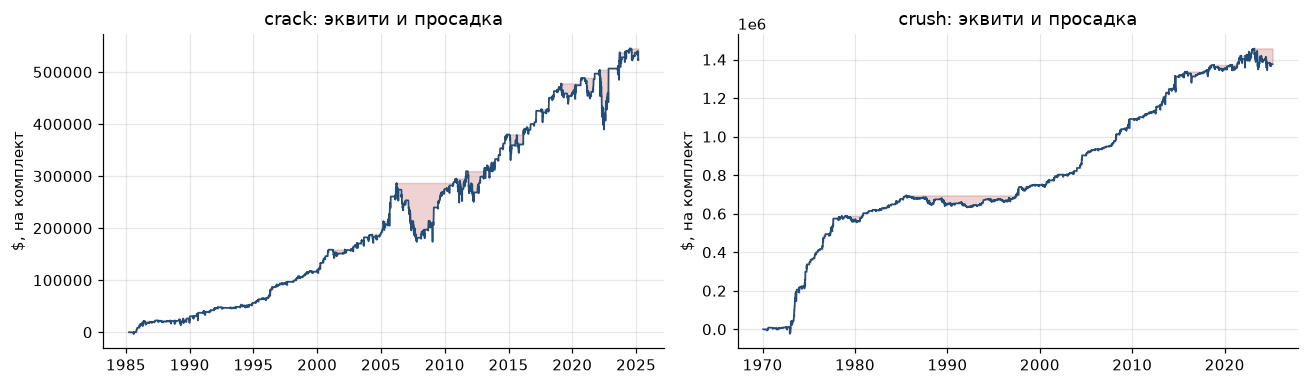

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, name in zip(axes, ['crack', 'crush']):
    r = globals()['res_' + name]
    ax.plot(r['equity'], lw=1.1, color='#1f4e79')
    ax.fill_between(r['equity'].index, r['equity'], r['equity'].cummax(), color='#c0504d', alpha=.25)
    ax.set_title(f'{name}: эквити и просадка')
    ax.set_ylabel('$, на комплект')
plt.tight_layout(); plt.show()

Расклад двойственный, и его надо разобрать целиком. По полной истории (crack 1985–2025, crush
с 1970-х) оба спреда
формально прибыльны: crack даёт около $+\$523$ тыс., crush — $+\$1.38$ млн на комплект, Sharpe
$\approx 0.43$ и $0.69$. Но это результат на **сорока–пятидесяти пяти годах** — за такой срок даже
слабое преимущество накапливается. Оговорка по источнику чисел: основной бэктест (и этот раздел, и
пункт 6) идёт на сборке `base_1`, где каждая нога роллируется сама по себе, поэтому и эти Sharpe, и
кривые эквити могут содержать roll-артефакт; его размер мы отдельно измеряем в пункте 5 как phantom. Средний P&L на сделку у crack при этом **отрицательный** ($-\$1\,330$):
стратегия зарабатывает не на типичной сделке, а на редких больших движениях — распределение P&L сильно
скошено, и среднее по сделкам не равно вкладу стратегии. Среднее удержание около 18 дней согласуется
с half-life в десятки дней: сигнал держится долго, зато и издержки платятся реже. Просадки, однако,
сопоставимы с итоговой прибылью (maxDD порядка $\$113$ тыс.) — то есть путь далеко не гладкий.

В пункте 6 результат разрезан по подпериодам: почти весь P&L приходит из
1995–2015, а после 2015 Sharpe падает до 0.31 и 0.14. Пока зафиксируем: движок работает, но результат
нестабилен во времени. Сначала докажем сам движок.

## Пункт 4 — доказательство корректности движка

Три теста ловят три разных класса ошибок. Каждый из них **падает** на конкретно
сломанной версии, которую слайд дня и перечисляет.

1. **Loop equality.** Векторный движок должен совпадать с наивным `for`-циклом по позициям и по P&L
   до последнего доллара. Если нет — в векторизации ошибка.
2. **Prefix-тест.** Считаем тот же бэктест на усечённом входе и проверяем, что прошлые позиции и P&L
   не изменились. Это тест на отсутствие заглядывания в будущее: информация не должна течь назад.
3. **Perturbation-тест.** Сдвигаем цену в баре $t$ и проверяем, что позиция, **заработавшая** бар $t$,
   не изменилась. Это тонкий, но решающий тест: он ловит ошибки выравнивания, которые prefix-тест
   пропускает.

In [12]:
# (a) Loop equality: векторный движок против явного цикла.
def loop_backtest(s, w=60, z_in=2.0, z_out=0.5, cost_usd=0.0):
    z = zscore(s, w)
    pos_out = np.zeros(len(s)); net_out = np.zeros(len(s))
    state, prev_pos, sv, zv = 0, 0, s.values, z.values
    for i in range(len(sv)):
        if not np.isnan(zv[i]):
            if state == 0:
                if zv[i] > z_in: state = -1
                elif zv[i] < -z_in: state = 1
            elif state == 1 and zv[i] > -z_out: state = 0
            elif state == -1 and zv[i] < z_out: state = 0
        pos_out[i] = state
        ds = 0.0 if i == 0 else sv[i] - sv[i-1]
        net_out[i] = prev_pos * ds - abs(state - prev_pos) * cost_usd
        prev_pos = state
    return pd.Series(pos_out, index=s.index), pd.Series(net_out, index=s.index)

for name, s in [('crack', crack), ('crush', crush)]:
    vec = backtest(s, cost_usd=COST[name])
    lp, ln = loop_backtest(s, cost_usd=COST[name])
    print(f'{name}: max|Δpos| = {(vec["pos"]-lp).abs().max()},  max|Δnet| = {(vec["net"]-ln).abs().max():.2e}')

crack: max|Δpos| = 0.0,  max|Δnet| = 0.00e+00
crush: max|Δpos| = 0.0,  max|Δnet| = 0.00e+00


In [13]:
# (b) Prefix-тест: усечённый вход не меняет прошлое. Проверяем три версии движка.
def prefix_test(s, frac=0.5, cost_usd=0.0, shift=True, whole=False):
    full = backtest(s, cost_usd=cost_usd, shift=shift, whole=whole)
    k = int(len(s) * frac)
    sub = backtest(s.iloc[:k], cost_usd=cost_usd, shift=shift, whole=whole)
    m = k - 1
    return (full['pos'].iloc[:m] - sub['pos'].iloc[:m]).abs().max(), \
           (full['net'].iloc[:m] - sub['net'].iloc[:m]).abs().max()

print('prefix-тест на crack (обрезка входной выборки вдвое):')
for lbl, sh, wh in [('корректный (rolling + shift)', True, False),
                    ('без shift', False, False),
                    ('whole-sample статистика', True, True)]:
    dp, dn = prefix_test(crack, 0.5, COST['crack'], shift=sh, whole=wh)
    print(f'  {lbl:30s}: max|Δpos|={dp:.0f}  max|Δnet|=${dn:,.0f}')

prefix-тест на crack (обрезка входной выборки вдвое):
  корректный (rolling + shift)  : max|Δpos|=0  max|Δnet|=$0
  без shift                     : max|Δpos|=0  max|Δnet|=$0
  whole-sample статистика       : max|Δpos|=1  max|Δnet|=$13,364


In [14]:
# (c) Perturbation-тест: шок цены в баре t не должен менять позицию, заработавшую бар t.
def perturbation_test(s, cost_usd=0.0, shift=True, whole=False, n=60, shock=15000.0, seed=1):
    rng = np.random.default_rng(seed)
    picks = rng.choice(np.arange(70, len(s) - 1), size=n, replace=False)
    base = backtest(s, cost_usd=cost_usd, shift=shift, whole=whole)['pos']
    changed = 0
    for p in picks:
        s2 = s.copy(); s2.iloc[p] += shock
        q = backtest(s2, cost_usd=cost_usd, shift=shift, whole=whole)['pos']
        # позиция, заработавшая бар p: со shift её задал бар p-1, без shift — сам бар p
        ip = p - 1 if shift else p
        changed += int(base.iloc[ip] != q.iloc[ip])
    return changed, n

print('perturbation-тест (60 случайных баров, шок +15 000 — около 6 средних дневных приращений, sd ≈ 2 600):')
for lbl, sh, wh in [('корректный (rolling + shift)', True, False),
                    ('без shift', False, False),
                    ('whole-sample статистика', True, True)]:
    ch, n = perturbation_test(crack, COST['crack'], shift=sh, whole=wh)
    print(f'  {lbl:30s}: изменено {ch}/{n}')

perturbation-тест (60 случайных баров, шок +15 000 — около 6 средних дневных приращений, sd ≈ 2 600):


  корректный (rolling + shift)  : изменено 0/60


  без shift                     : изменено 40/60


  whole-sample статистика       : изменено 0/60


Результаты надо читать вместе: по отдельности они обманчивы.

**Loop equality** проходит идеально для обоих спредов: разница позиций ровно ноль, разница P&L — ноль
до машинной точности. Векторизация ничего не сломала.

**Prefix-тест** на корректном движке проходит: усечение входа не меняет ни одной прошлой позиции. И
здесь есть тонкость: версия **без shift** его тоже проходит — потому что отсутствие сдвига не тянет
информацию из будущего в прошлое, это ошибка *внутри* бара, а не во времени. Зато версия с
**whole-sample статистикой падает**: max|Δpos| = 1 и расхождение P&L $\approx \$13\,364$. Понятно
почему — whole-sample среднее и sd зависят от всей выборки, поэтому обрезка будущего меняет значения z
на прошлых барах, а значит меняет и прошлые позиции. Это и есть hindsight: стратегия «уже знала» про
будущий уровень.

**Perturbation-тест** закрывает дыру, которую оставил prefix. Корректный движок: 0 из 60 позиций
изменилось — шок в баре $t$ не трогает позицию, которая бар $t$ заработала. Версия **без shift**
падает: 40 из 60 позиций изменились. Причина именно в ошибке выравнивания: без shift позиция бара $t$
считается по $z_t$, который включает $\Delta s_t$, поэтому шок цены немедленно переписывает позицию
того же бара — движок «торгует» ценой, которую сам же и сдвинул. Whole-sample статистика на этом тесте,
наоборот, проходит (0/60), потому что шок одного бара почти не меняет среднее и sd всей выборки.

Складываем: **ни один тест по отдельности не ловит все ошибки**. Prefix ловит hindsight, но пропускает
timing; perturbation ловит timing, но пропускает hindsight; loop equality проверяет только реализацию.
Нужны оба теста вместе — и это практический вывод дня.

## Пункт 5 — ломаем наивную сборку роллов

Здесь показываем phantom P&L — призрачный P&L, который возникает из ошибок выравнивания роллов.
Механизм: если ноги роллятся в разные дни, в день ролла одной ноги в спреде появляется скачок, которого
не было на рынке. Стратегия видит его как отклонение от среднего, входит — и торгует не рынком, а
разницей цен двух разных контрактов.

На реальных данных дат экспирации нет, поэтому мы **не можем** утверждать, какая
из двух сборок (aligned или naive) «правильная по календарю» — обе используют один и тот же front-код.
Две оговорки. Первая: aligned-сборка построена эвристикой — расписание роллов взято из фактических
переключений front-контракта CL, потому что дат экспирации в выдаче нет; это единое правило для всех
ног, но не календарный эталон. Вторая: синтетический механизм (медленный OU-спред без преимущества,
half-life $\approx 60$ дней, ролл-гэпы ног размера $g$ сигм) — именно синтетика, она нужна, чтобы
показать зависимость phantom от размера гэпа при нулевом честном сигнале. На реальных рядах ниже мы
тем не менее гоняем обе сборки через тот же движок и измеряем phantom P&L напрямую, а не только
«рваность» серии.

In [15]:
# Масштаб на реальных данных: насколько наивная сборка «рванее» согласованной.
common = crack_aligned.index.intersection(crack_naive.index)
a, v = crack_aligned.reindex(common), crack_naive.reindex(common)
print('реальные данные (2000+):')
print(f'  max |дневное изменение|: aligned ${a.diff().abs().max():,.0f}  naive ${v.diff().abs().max():,.0f}')
print(f'  99.9-й перцентиль |Δ|:   aligned ${a.diff().abs().quantile(.999):,.0f}  naive ${v.diff().abs().quantile(.999):,.0f}')
print(f'  sd уровня:               aligned ${a.std():,.0f}  naive ${v.std():,.0f}  (почти совпадают)')
print(f'  сумма |Δ| за период:     aligned ${a.diff().abs().sum():,.0f}  naive ${v.diff().abs().sum():,.0f}')

# Phantom P&L на реальных рядах: обе сборки через тот же честный движок (rolling z + shift(1)).
r_al, r_nv = backtest(a, cost_usd=COST['crack']), backtest(v, cost_usd=COST['crack'])
phantom = r_nv['net'].sum() - r_al['net'].sum()
print(f'  P&L движка: aligned ${r_al["net"].sum():,.0f}  naive ${r_nv["net"].sum():,.0f}')
print(f'  phantom (naive − aligned) = ${phantom:,.0f}, это {phantom/abs(r_al["net"].sum())*100:+.0f}% от честного — nonzero и по масштабу сравним с прибылью')

# Доля phantom, приходящаяся на горстку ролл-скачков: топ-30 дней по величине гэпа
# |Δ(naive − aligned)| — ровно те дни, где сборки разошлись сильнее всего.
d_ph = (r_nv['net'] - r_al['net']).fillna(0.0)
gap_abs = (v - a).diff().abs()
top30 = gap_abs.nlargest(30).index
print(f'  топ-30 дней по гэпу |Δ(naive−aligned)|: {d_ph[top30].abs().sum()/d_ph.abs().sum()*100:.1f}%'
      f' от суммы |дневного phantom|')

реальные данные (2000+):
  max |дневное изменение|: aligned $28,525  naive $64,665
  99.9-й перцентиль |Δ|:   aligned $20,920  naive $20,706
  sd уровня:               aligned $28,365  naive $29,067  (почти совпадают)
  сумма |Δ| за период:     aligned $12,628,890  naive $13,023,197
  P&L движка: aligned $535,340  naive $389,609
  phantom (naive − aligned) = $-145,730, это -27% от честного — nonzero и по масштабу сравним с прибылью
  топ-30 дней по гэпу |Δ(naive−aligned)|: 11.3% от суммы |дневного phantom|


In [16]:
# Синтетика: медленный OU + ролл-гэпы у ног. aligned = ноги роллятся вместе, naive = вразнобой.
def make_synth(T=6000, gap_sd=1.0, spacing=60, sd=60.0, hl=60, seed=0):
    rng = np.random.default_rng(seed)
    phi = 0.5 ** (1.0 / hl)
    e = rng.normal(0, sd * np.sqrt(1 - phi**2), T)
    x = np.zeros(T)
    for t in range(1, T):
        x[t] = phi * x[t-1] + e[t]
    honest = pd.Series(x, index=pd.RangeIndex(T))
    rollA, rollB = np.arange(spacing, T, spacing), np.arange(spacing // 2, T, spacing)
    gA, gB = np.zeros(T), np.zeros(T)
    for r in rollA: gA[r:] += rng.normal(0, gap_sd * sd)
    for r in rollB: gB[r:] += rng.normal(0, gap_sd * sd)
    naive = honest + pd.Series(gA - gB, index=honest.index)
    return honest, naive, rollA, rollB

rows = []
for gap in [0.0, 0.5, 1.0, 2.0]:
    aligned_net, naive_net, near = [], [], []
    for rep in range(200):
        honest, naive, rollA, rollB = make_synth(gap_sd=gap, seed=rep)
        na = backtest(honest, cost_usd=0.0)['net']
        nn = backtest(naive, cost_usd=0.0)['net']
        pn = backtest(naive, cost_usd=0.0)['pos']
        aligned_net.append(na.sum()); naive_net.append(nn.sum())
        ch = pn.diff().abs().fillna(0)
        mask = np.zeros(len(naive), bool)
        for r in list(rollA) + list(rollB): mask[max(0, r-3):r+3] = True
        near.append(ch[mask].sum() / max(1e-9, ch.sum()))
    an, nv = np.array(aligned_net), np.array(naive_net)
    rows.append({'ролл-гэп, sd': gap, 'aligned P&L': f"${an.mean():,.0f}",
                 'naive P&L': f"${nv.mean():,.0f}", 'phantom, $': f"${(nv-an).mean():,.0f}",
                 'phantom / |aligned|': f'{abs(nv-an).mean()/abs(an).mean()*100:.0f}%',
                 'входы у ролла': f'{np.mean(near)*100:.0f}%'})
display(pd.DataFrame(rows))

,"ролл-гэп, sd",aligned P&L,naive P&L,"phantom, $",phantom / |aligned|,входы у ролла
0,0.0,"$1,137","$1,137",$0,0%,20%
1,0.5,"$1,137",$941,$-196,35%,34%
2,1.0,"$1,137",$697,$-441,58%,51%
3,2.0,"$1,137",$430,$-707,103%,68%


В таблице механизм виден сразу. При нулевом гэпе (ролл идеально непрерывен) phantom равен
нулю. Но при гэпе в 0.5 sd phantom P&L вырастает до трети от честного, при 1 sd — больше половины, при
2 sd — **превышает 100%**: наивная сборка не просто добавляет шум, она переворачивает знак результата.
Одновременно доля входов, приходящихся на окно вокруг даты ролла, растёт с 20% до 68% — то есть
стратегия всё чаще торгует именно ролл-гэп, а не сам спред.

На реальных рядах phantom тоже велик: за 2000–2025 тот же движок даёт aligned $535,340
против naive $389,609 — расхождение $\approx \$146$ тыс., четверть (−27%) честного результата. Знак
здесь **отрицательный**: рассинхронизация роллов у нас не добавила прибыль, а уменьшила её. Это,
возможно, даже важнее положительного phantom: ошибка выравнивания — не баг в пользу результата, а
надбавка с непредсказуемым знаком, на которой нельзя ни строить, ни отнимать. При этом по дням эффект
не сводится к горстке ролл-скачков: топ-30 дней по гэпу |Δ(naive − aligned)| дают лишь 11.3% суммы
|дневного phantom| (посчитано в ячейке выше) — гэпы просачиваются в позиции через z-score окном в 60 дней и живут потом долго.

Это тот самый «гладкий, но бессмысленный» результат: equity красиво растёт, Sharpe получается
приличным, а источник дохода — не рынок, а бухгалтерский скачок между двумя контрактами. На реальных
данных гэпы свои и до конца не идентифицированы (дат экспирации нет), поэтому синтетика выше — не
замена реальному измерению, а калибровка механизма: сколько phantom стоит при гэпе заданного размера.
Единственная защита — **единое правило ролла для всех ног**, и именно так устроена конструкция
`spread_usd` из пункта 1.

## Пункт 6 — оценка результата: Sharpe с интервалом, in/out-of-sample, число вариантов

Последний и самый неудобный пункт. Даже корректный Sharpe не говорит, что стратегия настоящая. Три
причины: у Sharpe широкая ошибка на коротких выборках; результат может держаться только на прошлом
(in-sample); и мы, перебирая окна и пороги, множим число попыток, среди которых лучшая всегда выглядит
хорошо.

**Интервал для Sharpe.** При неизвестном истинном Sharpe $\mathrm{SR}$ и $T$ годах данных ошибка
оценки примерно $\mathrm{sd} \approx \sqrt{(1 + \mathrm{SR}^2/504)/T}$. Уже при $\mathrm{SR}=1$ и $T=1$
90%-й интервал $-0.65\ldots2.65$ — то есть даже «единица» не отличима от нуля на годовой истории.
Плюс к этому вероятность $\mathrm{SR}<0$: при $T=1$ это 16%.

In [17]:
def sharpe_ci(sr, years, conf=0.90):
    sd = np.sqrt((1 + sr**2 / 504) / years)
    z = norm.ppf((1 + conf) / 2)
    return sr - z * sd, sr + z * sd, sd

print('иллюстрация слайда: истинный SR=1, разные T')
for T in [1, 3, 10]:
    lo, hi, sd = sharpe_ci(1.0, T)
    print(f'  T={T:2d} лет: sd≈{sd:.2f}  90%CI=[{lo:.2f}, {hi:.2f}]  P(SR<0)={norm.cdf(-1.0/sd):.2f}')

print('\nнаши спреды: Sharpe и его 90%-й интервал по числу лет данных')
for name, s in [('crack', crack), ('crush', crush)]:
    r = backtest(s, cost_usd=COST[name])
    years = (s.index[-1] - s.index[0]).days / 365.25
    sr = ann_sharpe(r['net'])
    lo, hi, sd = sharpe_ci(sr, years)
    print(f'  {name}: SR={sr:.2f} за {years:.0f} лет  90%CI=[{lo:.2f}, {hi:.2f}]')

иллюстрация слайда: истинный SR=1, разные T
  T= 1 лет: sd≈1.00  90%CI=[-0.65, 2.65]  P(SR<0)=0.16
  T= 3 лет: sd≈0.58  90%CI=[0.05, 1.95]  P(SR<0)=0.04
  T=10 лет: sd≈0.32  90%CI=[0.48, 1.52]  P(SR<0)=0.00

наши спреды: Sharpe и его 90%-й интервал по числу лет данных
  crack: SR=0.43 за 40 лет  90%CI=[0.17, 0.69]
  crush: SR=0.69 за 55 лет  90%CI=[0.47, 0.91]


In [18]:
# In-sample / out-of-sample: режем по 2015 году, плюс разбивка по десятилетиям.
cut = pd.Timestamp('2015-01-01')
rows = []
for name, s in [('crack', crack), ('crush', crush)]:
    net = backtest(s, cost_usd=COST[name])['net']
    ins, oos = net[net.index < cut], net[net.index >= cut]
    rows.append(dict(спред=name, Sharpe_full=round(ann_sharpe(net), 2),
                     Sharpe_in=round(ann_sharpe(ins), 2), Sharpe_out=round(ann_sharpe(oos), 2),
                     net_in=f"${ins.sum():,.0f}", net_out=f"${oos.sum():,.0f}"))
display(pd.DataFrame(rows))

rows = []
for name, s in [('crack', crack), ('crush', crush)]:
    net = backtest(s, cost_usd=COST[name])['net']
    for lo, hi in [(1985, 1995), (1995, 2005), (2005, 2015), (2015, 2026)]:
        m = (net.index >= pd.Timestamp(f'{lo}-01-01')) & (net.index < pd.Timestamp(f'{hi}-01-01'))
        if m.sum() > 0:
            rows.append(dict(спред=name, период=f'{lo}–{hi}', n=int(m.sum()),
                             Sharpe=round(ann_sharpe(net[m]), 2), net=f"${net[m].sum():,.0f}"))
display(pd.DataFrame(rows))

,спред,Sharpe_full,Sharpe_in,Sharpe_out,net_in,net_out
0,crack,0.43,0.54,0.31,"$379,919","$143,086"
1,crush,0.69,0.87,0.14,"$1,311,732","$64,405"


,спред,период,n,Sharpe,net
0,crack,1985–1995,2462,0.60,"$56,574"
1,crack,1995–2005,2500,1.01,"$134,231"
2,crack,2005–2015,2521,0.51,"$189,114"
3,crack,2015–2026,2559,0.31,"$143,086"
4,crush,1985–1995,2533,-0.07,"$-12,864"
5,crush,1995–2005,2470,1.11,"$243,140"
6,crush,2005–2015,2525,0.86,"$405,019"
7,crush,2015–2026,2559,0.14,"$64,405"


In/out-of-sample разрыв — самое отрезвляющее число дня. У crack Sharpe падает с 0.54 в in-sample до
0.31 после 2015; у crush — с 0.87 до 0.14. По десятилетиям видно, что почти весь доход crush
собран в 1995–2015, а в 2015–2025 от него остаётся десятая часть (у crush история с 1970-х, и
десятилетия 1970–1985 в этой таблице уже не помещаются — они учтены в in-sample).
Причина простая: processing-спреды в 2020-е стали ликвиднее и эффективнее, а издержки на
комплект в долларах не изменились — преимущество в значительной мере выкуплено рынком.

**Число испробованных вариантов.** Наконец, посчитаем сам перебор. Чтобы не рассуждать о
data snooping абстрактно, мы и сами переберём сетку: 5 окон × 4 порогов входа × 3 порога выхода = 60
комбинаций на спред, то есть 120 вариантов вместе с тестовым базовым конфигом; плюс два разреза по
периодам. Выберем лучший конфиг по in-sample Sharpe (до 2015) и посмотрим, что он покажет на
out-of-sample. Слайд дня приводит оценку для 10 окон × 5 входов × 3 выхода = 150 вариантов; при такой
переборке лучший результат почти наверняка выглядит значимым даже на чистом шуме: уже при 20 вариантах
ожидаемый максимум t-статистики около 2.05, а шанс найти «значимый» результат превышает 60%; при 100
вариантах — около 99%. Посчитаем и это явно. Единственная попытка ($N=1$) обрабатывается отдельно:
максимум одного $t$ — это само $|t|$, и его матожидание для стандартной нормали равно
$\sqrt{2/\pi} \approx 0.80$, тогда как приближенная формула $\Phi^{-1}(1 - 1/(2.5N))$ рассчитана
на $N > 1$ и при $N=1$ даёт бессмысленные $0.25$.

In [19]:
print('ожидаемый максимум |t| при N независимых попытках (нулевой эффект) и шанс любой значимости:')
for N in [1, 10, 20, 100, 150]:
    emax = norm.ppf(1 - 1/(N * 2.5)) if N > 1 else np.sqrt(2 / np.pi)  # N=1: матожидание |t| самого
    p_any = 1 - (1 - 0.05) ** N
    print(f'  N={N:3d}: E[max|t|]≈{emax:.2f}   P(хотя бы один p<0.05)={p_any*100:.0f}%')
print('\nслайд: 10 окон × 5 входов × 3 выхода = 150 вариантов — при таком переборе')
print('лучший t уже неотличим от шума.')
# Реальный перебор: 5 окон x 4 входа x 3 выхода = 60 комбинаций на спред; выбираем по in-sample (до 2015).
cut = pd.Timestamp('2015-01-01')
rows = []
for name, s in [('crack', crack), ('crush', crush)]:
    best = None
    for w in [20, 40, 60, 90, 120]:
        for zi in [1.5, 2.0, 2.5, 3.0]:
            for zo in [0.25, 0.5, 1.0]:
                net = backtest(s, w=w, z_in=zi, z_out=zo, cost_usd=COST[name])['net']
                sr_in = ann_sharpe(net[net.index < cut])
                if best is None or sr_in > best[0]:
                    best = (sr_in, w, zi, zo, net)
    sr_in, w, zi, zo, net = best
    oos = net[net.index >= cut]
    base = backtest(s, cost_usd=COST[name])['net']
    rows.append(dict(спред=name, лучшие_параметры=f'W={w}, z_in={zi}, z_out={zo}',
                     Sharpe_in=round(sr_in, 2), Sharpe_out=round(ann_sharpe(oos), 2),
                     net_out=f'${oos.sum():,.0f}',
                     базовый_Sharpe_out=round(ann_sharpe(base[base.index >= cut]), 2)))
display(pd.DataFrame(rows))
print('trials: 60 комбинаций x 2 спреда = 120 перебранных вариантов (плюс разрезы по периодам)')
print('вывод: выбранный по in-sample оптимум на out-of-sample ХУЖЕ базового конфига —')
print('перебор покупает красивое прошлое и отдаёт будущее.')

ожидаемый максимум |t| при N независимых попытках (нулевой эффект) и шанс любой значимости:
  N=  1: E[max|t|]≈0.80   P(хотя бы один p<0.05)=5%
  N= 10: E[max|t|]≈1.75   P(хотя бы один p<0.05)=40%
  N= 20: E[max|t|]≈2.05   P(хотя бы один p<0.05)=64%
  N=100: E[max|t|]≈2.65   P(хотя бы один p<0.05)=99%
  N=150: E[max|t|]≈2.79   P(хотя бы один p<0.05)=100%

слайд: 10 окон × 5 входов × 3 выхода = 150 вариантов — при таком переборе
лучший t уже неотличим от шума.


,спред,лучшие_параметры,Sharpe_in,Sharpe_out,net_out,базовый_Sharpe_out
0,crack,"W=120, z_in=2.5, z_out=0.5",0.72,0.22,"$79,129",0.31
1,crush,"W=40, z_in=1.5, z_out=0.5",1.07,0.09,"$48,670",0.14


trials: 60 комбинаций x 2 спреда = 120 перебранных вариантов (плюс разрезы по периодам)
вывод: выбранный по in-sample оптимум на out-of-sample ХУЖЕ базового конфига —
перебор покупает красивое прошлое и отдаёт будущее.


## Выводы и ограничения

Собираем итог дня.

**Что получилось содержательно.** Спреды действительно медленно возвращаются к среднему: half-life
82–176 дней на полной истории и 58–72 дня после 2015. Но это **слабая** реверсия: ADF отвергает
случайное блуждание, а KPSS одновременно отвергает стационарность, то есть процесс не блуждает и не
стабилизируется, а медленно дрейфует. Доля дней $|z|>2$ (12.4% и 12.3%) практически совпадает с контролем —
случайным блужданием (13.7–13.8%) — значит, частота сигналов сама по себе ничего не доказывает.

**Что с движком.** Векторный конвейер «позиция × приращение» корректен: он совпадает с явным циклом до
машинной точности и проходит prefix- и perturbation-тесты. Ошибка без `shift(1)` ломает perturbation
(40/60), но prefix проходит; ошибка whole-sample статистики ломает prefix (расхождение P&L
$\approx \$13\,364$), но проходит perturbation. Значит, **корректность движка доказывает только
комбинацией тестов** — и это главный вывод, который стоит унести из дня 8.

**Что с результатом.** По полной истории стратегия формально прибыльна (Sharpe 0.43 и 0.69), но
in/out-of-sample разрыв большой (crush: 0.87 → 0.14), а после 2015 преимущество почти исчезает. Наш
собственный перебор 120 вариантов это подтверждает: конфигурация, лучшая по in-sample, в out-of-sample
оказывается **хуже** базовой (crush: 0.09 против 0.14). С учётом числа перебранных вариантов и широких
интервалов Sharpe это **слабый, неустойчивый результат, близкий к null** — и мы докладываем его именно
так, а не подгоняем параметрами до красивой картинки.

**Ограничения.**

1. **Дат экспирации нет.** Мы не можем проверить, какое расписание роллов соответствует реальному
   календарю; aligned-сборка использует эвристику «роллить все ноги вместе с front-кодом CL». Поэтому
   на реальных данных мы сравниваем две сборки между собой (phantom $\approx -\$146$ тыс., −27% от
   честного P&L за 2000–2025), а абсолютную «правильную» сборку не утверждаем; калибровка механизма по
   размеру гэпа — на синтетике, и она подписана как синтетика.
2. **Издержки иллюстративны.** $\$2.50$/контракт и slippage в один тик на ногу — заявленные допущения,
   а не биржевые факты; $c$ в движке — стоимость одной стороны, полный цикл стоит $2c$. При удвоении
   издержек Sharpe падает с 0.43 до 0.41 (crack) и с 0.69 до 0.58 (crush) — выводы дня от этого не
   меняются. Чувствительность мала в относительных числах: суммарные издержки crack ($23$ тыс.) —
   лишь ~4% валового P&L ($546$ тыс. до издержек) при ~200 сделках за 40 лет, поэтому их удвоение
   снимает только $0.02$ Sharpe; у crush доля заметнее (~14% валового), и падение сильнее
   ($0.69 \to 0.58$), но и там вывод не меняется, потому что издержки одинаковы для обоих периодов.
3. **`base_1` — склейка, а не реально торгуемый инструмент.** Мы используем её для длины истории, но
   осознаём, что при переключении front-контракта уровень серии меняется бухгалтерски.
4. **Дневные settlement-цены.** Никакого intraday-исполнения: вход и выход по close, без проскальзывания
   внутри дня и без учёта ликвидности — на дневном горизонте это приемлемая идеализация, но она
   систематически завышает результат.

Итог в одну строку: **движок бэктеста мы построили и доказали, а торговое преимущество спредов не
подтвердили.** Для домашки про движок это ровно тот результат, который и должен был получиться.

In [20]:
print('=== сводка дня 8 ===')
print('hand-check:  crack $52 227, crush $68 827 (unit-тест пройден)')
print('ловушка центов: crush уезжает в -$27 млн без множителя 0.01')
for name, s in [('crack', crack), ('crush', crush)]:
    r = backtest(s, cost_usd=COST[name])
    yrs = (s.index[-1] - s.index[0]).days / 365.25
    sr = ann_sharpe(r['net']); lo, hi, _ = sharpe_ci(sr, yrs)
    print(f'{name}: SR={sr:.2f} 90%CI=[{lo:.2f},{hi:.2f}]  equity=${r["equity"].iloc[-1]:,.0f}  '
          f'maxDD=${(r["equity"]-r["equity"].cummax()).min():,.0f}')
print('движок: loop equality OK; prefix ловит whole-sample; perturbation ловит отсутствие shift')
print('phantom (синтетика): 0.5/1/2 sd -> 34/58/103% от честного P&L')
print('phantom (реальные ряды 2000+): naive − aligned = −$145,730 (−27% честного P&L) — знак непредсказуем')
print('trials: перебор 120 вариантов; in-sample оптимум в out-of-sample хуже базового конфига')

=== сводка дня 8 ===
hand-check:  crack $52 227, crush $68 827 (unit-тест пройден)
ловушка центов: crush уезжает в -$27 млн без множителя 0.01
crack: SR=0.43 90%CI=[0.17,0.69]  equity=$523,004  maxDD=$-114,485
crush: SR=0.69 90%CI=[0.47,0.91]  equity=$1,376,138  maxDD=$-112,845
движок: loop equality OK; prefix ловит whole-sample; perturbation ловит отсутствие shift
phantom (синтетика): 0.5/1/2 sd -> 34/58/103% от честного P&L
phantom (реальные ряды 2000+): naive − aligned = −$145,730 (−27% честного P&L) — знак непредсказуем
trials: перебор 120 вариантов; in-sample оптимум в out-of-sample хуже базового конфига
